<a href="https://colab.research.google.com/github/krithimani07-crypto/CODSOFT/blob/main/Spam_sms_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- basic setup ---
import pandas as pd
import numpy as np

# --- text handling ---
from sklearn.feature_extraction.text import TfidfVectorizer

# --- splitting ---
from sklearn.model_selection import train_test_split

# --- models ---
from sklearn.naive_bayes import MultinomialNB

# --- evaluation ---
from sklearn.metrics import accuracy_score

In [35]:
import zipfile

zip_file = "spam.csv.zip"   #  correct name (your file)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data_folder")

print("Extraction Done ")

Extraction Done 


In [4]:
import zipfile
from google.colab import files

uploaded = files.upload()

# auto get file name
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data_folder")

print("✔ Extracted:", zip_file)

Saving spam.csv.zip to spam.csv (1).zip
✔ Extracted: spam.csv (1).zip


In [5]:
import os

print(os.listdir("data_folder"))

['spam.csv']


In [6]:
import pandas as pd

file_path = "data_folder/spam.csv"

data = pd.read_csv(file_path, encoding='latin-1')

print(data.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [7]:
data = data[['v1', 'v2']]
data.columns = ['label', 'message']

print(data.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

print("✔ Labels converted")

✔ Labels converted


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['message'])
y = data['label']

print("✔ Text converted")

✔ Text converted


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

print("✔ Data split done")

✔ Data split done


In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

print("✔ Model trained")

✔ Model trained


In [12]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.968609865470852


In [36]:
def predict_sms(text):
    vec = vectorizer.transform([text])
    result = model.predict(vec)[0]

    return "SPAM " if result == 1 else "HAM "

print(predict_sms("Win cash now!!!"))
print(predict_sms("Are you coming to class?"))

SPAM 
HAM 


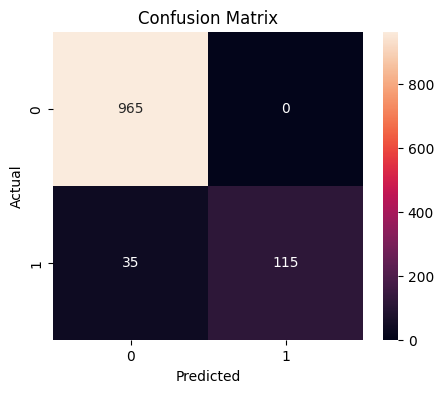

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
from sklearn.metrics import classification_report

report = classification_report(y_test, pred)

print(" Classification Report:\n")
print(report)

 Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [38]:
def smart_predict(msg):
    vec = vectorizer.transform([msg])

    result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]

    if prob > 0.8:
        level = "HIGH SPAM "
    elif prob > 0.5:
        level = "MEDIUM RISK "
    else:
        level = "SAFE "

    return f"{level} (Spam Score: {prob:.2f})"

print(smart_predict("Congratulations! You won 1 lakh"))

MEDIUM RISK  (Spam Score: 0.54)


In [39]:
# --- get important spam words ---
feature_names = vectorizer.get_feature_names_out()
weights = model.feature_log_prob_[1]

top_words = sorted(zip(weights, feature_names), reverse=True)[:10]

print(" Top Spam Words:")
for w in top_words:
    print(w[1])

 Top Spam Words:
free
txt
mobile
claim
stop
text
prize
ur
reply
www


In [21]:
# --- create new feature ---
data['msg_length'] = data['message'].apply(len)

# --- combine with TF-IDF ---
import scipy.sparse as sp

length_feature = sp.csr_matrix(data['msg_length'].values.reshape(-1,1))

X_combined = sp.hstack((X, length_feature))

print(" Hybrid features created")

 Hybrid features created


In [22]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_combined, y, test_size=0.2, random_state=21
)

model2 = MultinomialNB()
model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)

from sklearn.metrics import accuracy_score
print(" Hybrid Accuracy:", accuracy_score(y_test2, pred2))

 Hybrid Accuracy: 0.8762331838565023


In [23]:
def pattern_flag(msg):
    spam_keywords = ["win", "free", "cash", "offer", "prize"]

    score = 0
    for word in spam_keywords:
        if word in msg.lower():
            score += 1

    return score

print(pattern_flag("Win free cash now!!!"))

3


In [24]:
def ultimate_detector(msg):
    vec = vectorizer.transform([msg])

    ml_result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]

    pattern_score = pattern_flag(msg)

    # --- combine logic ---
    if ml_result == 1 or pattern_score >= 2:
        decision = "SPAM "
    else:
        decision = "SAFE "

    return f"{decision} | ML:{prob:.2f} | Pattern:{pattern_score}"

print(ultimate_detector("Free cash prize waiting!!!"))

SPAM  | ML:0.75 | Pattern:3


In [25]:
print("Normal Model Accuracy:", accuracy_score(y_test, pred))
print("Hybrid Model Accuracy:", accuracy_score(y_test2, pred2))

Normal Model Accuracy: 0.968609865470852
Hybrid Model Accuracy: 0.8762331838565023


In [27]:
# --- basic TF-IDF ---
tfidf_basic = TfidfVectorizer(stop_words='english')

X_basic = tfidf_basic.fit_transform(data['message'])

# --- split ---
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_basic, y, test_size=0.2, random_state=5
)

# --- train ---
basic_model = MultinomialNB()
basic_model.fit(Xb_train, yb_train)

# --- predict ---
basic_pred = basic_model.predict(Xb_test)

# --- accuracy ---
from sklearn.metrics import accuracy_score
basic_acc = accuracy_score(yb_test, basic_pred)

print(" Normal Model Accuracy:", basic_acc)


 Normal Model Accuracy: 0.9695067264573991


In [28]:
# --- improved TF-IDF ---
tfidf_adv = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1,2)
)

X_adv = tfidf_adv.fit_transform(data['message'])

# --- extra feature ---
data['length'] = data['message'].apply(len)

import scipy.sparse as sp
length_feat = sp.csr_matrix(data['length'].values.reshape(-1,1))

# --- combine ---
X_final = sp.hstack((X_adv, length_feat))

# --- split ---
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_final, y, test_size=0.2, random_state=11
)

# --- train ---
adv_model = MultinomialNB()
adv_model.fit(Xa_train, ya_train)

# --- predict ---
adv_pred = adv_model.predict(Xa_test)

# --- accuracy ---
adv_acc = accuracy_score(ya_test, adv_pred)

print(" Advanced Model Accuracy:", adv_acc)

 Advanced Model Accuracy: 0.9713004484304932


In [29]:
print("\n MODEL COMPARISON")
print("----------------------")
print(f"Normal Accuracy   : {basic_acc:.4f}")
print(f"Advanced Accuracy : {adv_acc:.4f}")

if adv_acc > basic_acc:
    print(" Advanced model performs better!")
else:
    print(" No improvement observed")


 MODEL COMPARISON
----------------------
Normal Accuracy   : 0.9695
Advanced Accuracy : 0.9713
 Advanced model performs better!


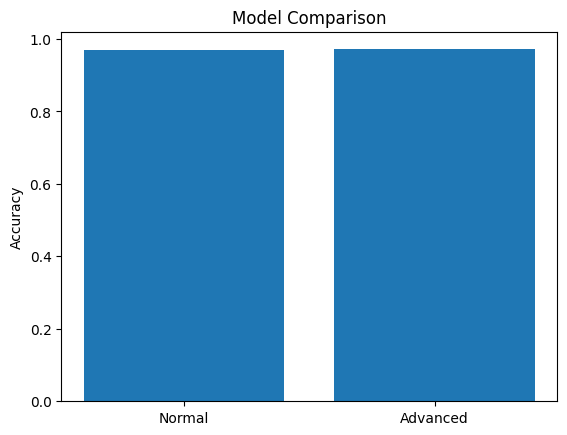

In [30]:
import matplotlib.pyplot as plt

models = ["Normal", "Advanced"]
scores = [basic_acc, adv_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [32]:
# --- create full result file ---
full_output = pd.DataFrame()

full_output['Message'] = data['message']
full_output['Actual_Label'] = y
full_output['Predicted_Label'] = model.predict(X)

# --- save ---
full_output.to_csv("spam_full_output.csv", index=False)

print(" Full output saved")

 Full output saved


In [33]:
# --- test results only ---
test_output = pd.DataFrame()

test_output['Actual'] = y_test
test_output['Predicted'] = pred

# --- save ---
test_output.to_csv("spam_test_output.csv", index=False)

print(" Test output saved")

 Test output saved


In [34]:
print("Model trained successfully")
print("Spam detection completed")

Model trained successfully
Spam detection completed
